### Capstone Project for Machine Learning with Databricks and MLflow Coursera Course

### Phase 1: Data Ingestion & Exploration
#### Load credit card fraud Kaggle dataset 
The dataset contains anonymized credit card transactions made by European cardholders in September 2013. The dataset includes 284,807 transactions, out of which 492 are fraudulent. The features are numerical and result from a PCA transformation, along with non-transformed time and amount features. The dataset is highly imbalanced, with a fraud rate of approximately 0.17%: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud.

For more detail on credit card fraud: https://fraud-detection-handbook.github.io/fraud-detection-handbook/Chapter_2_Background/CreditCardFraud.html. 

In [0]:
df_spark = spark.read.csv("/Users/adamhu/Downloads/creditcard.csv", header=True, inferSchema=True)

#### Exploratory Data Analysis (EDA)
##### Summary Stats & Class distribution 

In [0]:
from pyspark.sql import functions as F

#inspect schema and basic stats
df_spark.printSchema()
display(df_spark.describe())

print("Null counts per column:")
display(df_spark.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df_spark.columns
]))

print("Class distribution via Spark:")
display(df_spark.groupBy('Class').count().orderBy('Class'))

root
 |-- Time: double (nullable = true)
 |-- V1: double (nullable = true)
 |-- V2: double (nullable = true)
 |-- V3: double (nullable = true)
 |-- V4: double (nullable = true)
 |-- V5: double (nullable = true)
 |-- V6: double (nullable = true)
 |-- V7: double (nullable = true)
 |-- V8: double (nullable = true)
 |-- V9: double (nullable = true)
 |-- V10: double (nullable = true)
 |-- V11: double (nullable = true)
 |-- V12: double (nullable = true)
 |-- V13: double (nullable = true)
 |-- V14: double (nullable = true)
 |-- V15: double (nullable = true)
 |-- V16: double (nullable = true)
 |-- V17: double (nullable = true)
 |-- V18: double (nullable = true)
 |-- V19: double (nullable = true)
 |-- V20: double (nullable = true)
 |-- V21: double (nullable = true)
 |-- V22: double (nullable = true)
 |-- V23: double (nullable = true)
 |-- V24: double (nullable = true)
 |-- V25: double (nullable = true)
 |-- V26: double (nullable = true)
 |-- V27: double (nullable = true)
 |-- V28: double (nulla

summary,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807,284807,284807,284807,284807,284807,284807,284807,284807,284807,284807,284807,284807,284807,284807,284807,284807,284807,284807,284807,284807,284807,284807,284807,284807,284807,284807,284807,284807,284807,284807
mean,94813.85957508067,1.0793597390487234E-15,3.0975708487492947E-16,-2.5546976072159132E-17,1.9798906455923326E-15,6.067406817137794E-16,1.4018903119597324E-15,-1.9958575056374323E-16,2.115608955975678E-17,-2.4564016250632697E-15,2.2055223366046444E-15,1.5072715882573888E-15,-1.2869289196350163E-15,1.6837053917557379E-15,1.1144868311479422E-15,4.681483365223161E-15,1.4406099475690985E-15,-2.618565047396311E-16,1.090536541080293E-15,9.647975182251346E-16,5.803953626393653E-16,2.864055520589715E-16,-5.316964395018119E-16,3.145471428884593E-16,4.456749810088386E-15,2.0118243656825316E-16,1.6324118538608558E-15,-3.3979474033477283E-16,-1.2633778010684946E-16,88.34961925093684,0.001727485630620034
stddev,47488.14595456617,1.9586958038574862,1.6513085794769973,1.5162550051777717,1.4158685749409203,1.3802467340314393,1.3322710897575754,1.2370935981826663,1.1943529026692035,1.098632089224319,1.0888497654025167,1.0207130277115584,0.9992013895301448,0.9952742301251535,0.9585956112570637,0.9153160116104391,0.8762528873883705,0.8493370636743893,0.8381762095288414,0.8140405007685785,0.7709250248871169,0.734524014371313,0.7257015604409116,0.6244602955949903,0.6056470678271602,0.5212780705409424,0.48222701326105744,0.4036324949650307,0.3300832641602509,250.12010924018838,0.041527189635465055
min,0.0,-56.407509631329,-72.7157275629303,-48.3255893623954,-5.68317119816995,-113.743306711146,-26.1605059358433,-43.5572415712451,-73.2167184552674,-13.4340663182301,-24.5882624372475,-4.79747346479757,-18.6837146333443,-5.79188120632084,-19.2143254902614,-4.49894467676621,-14.1298545174931,-25.1627993693248,-9.49874592104677,-7.21352743017759,-54.497720494566,-34.8303821448146,-10.933143697655,-44.8077352037913,-2.83662691870341,-10.2953970749851,-2.60455055280817,-22.5656793207827,-15.4300839055349,0.0,0
max,172792.0,2.45492999121121,22.0577289904909,9.38255843282114,16.8753440335975,34.8016658766686,73.3016255459646,120.589493945238,20.0072083651213,15.5949946071278,23.7451361206545,12.0189131816199,7.8483920756446,7.12688295859376,10.5267660517847,8.87774159774277,17.3151115176278,9.25352625047285,5.04106918541184,5.59197142733558,39.4209042482199,27.2028391573154,10.5030900899454,22.5284116897749,4.58454913689817,7.51958867870916,3.5173456116238,31.6121981061363,33.8478078188831,25691.16,1


Null counts per column:


Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Class distribution via Spark:


Class,count
0,284315
1,492


Class Distribution
Class
0    284315
1       492
Name: count, dtype: int64
Fraud rate: 0.173%


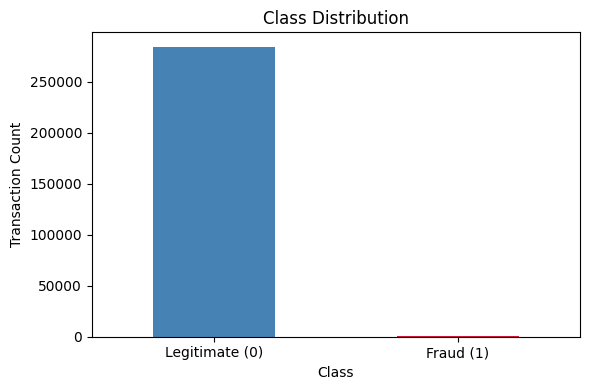

Amount statistics by class:


count,mean,std,min,25%,50%,75%,max
284315.0,88.29102242231328,250.10509222589243,0.0,5.65,22.0,77.05,25691.16
492.0,122.21132113821139,256.6832882977121,0.0,1.0,9.25,105.89,2125.87


In [0]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns 

#convert to pandas df to keep computation distributed for optimal runtime efficiency 
df = df_spark.toPandas()

print('Class Distribution')
print(df['Class'].value_counts())
print(f"Fraud rate: {df['Class'].mean() * 100:.3f}%")

fig, ax = plt.subplots(figsize=(6, 4))
df['Class'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'crimson'])
ax.set_xticklabels(['Legitimate (0)', 'Fraud (1)'], rotation=0)
ax.set_title('Class Distribution')
ax.set_ylabel('Transaction Count')
plt.tight_layout()
plt.show()

print("Amount statistics by class:")
display(df.groupby('Class')['Amount'].describe())

##### Amount and Time Distributions by Class 

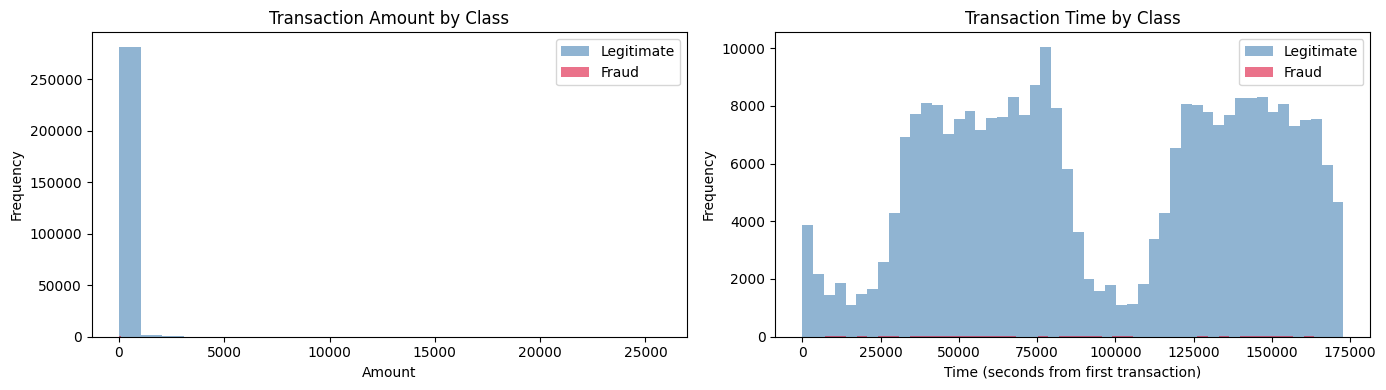

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for cls, label, color in [(0, 'Legitimate', 'steelblue'), (1, 'Fraud', 'crimson')]:
    subset = df[df['Class'] == cls]
    axes[0].hist(subset['Amount'], bins=25, alpha=0.6, label=label, color=color)
    axes[1].hist(subset['Time'], bins=50, alpha=0.6, label=label, color=color)

axes[0].set_title('Transaction Amount by Class')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].set_title('Transaction Time by Class')
axes[1].set_xlabel('Time (seconds from first transaction)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

##### Correlation heatmap

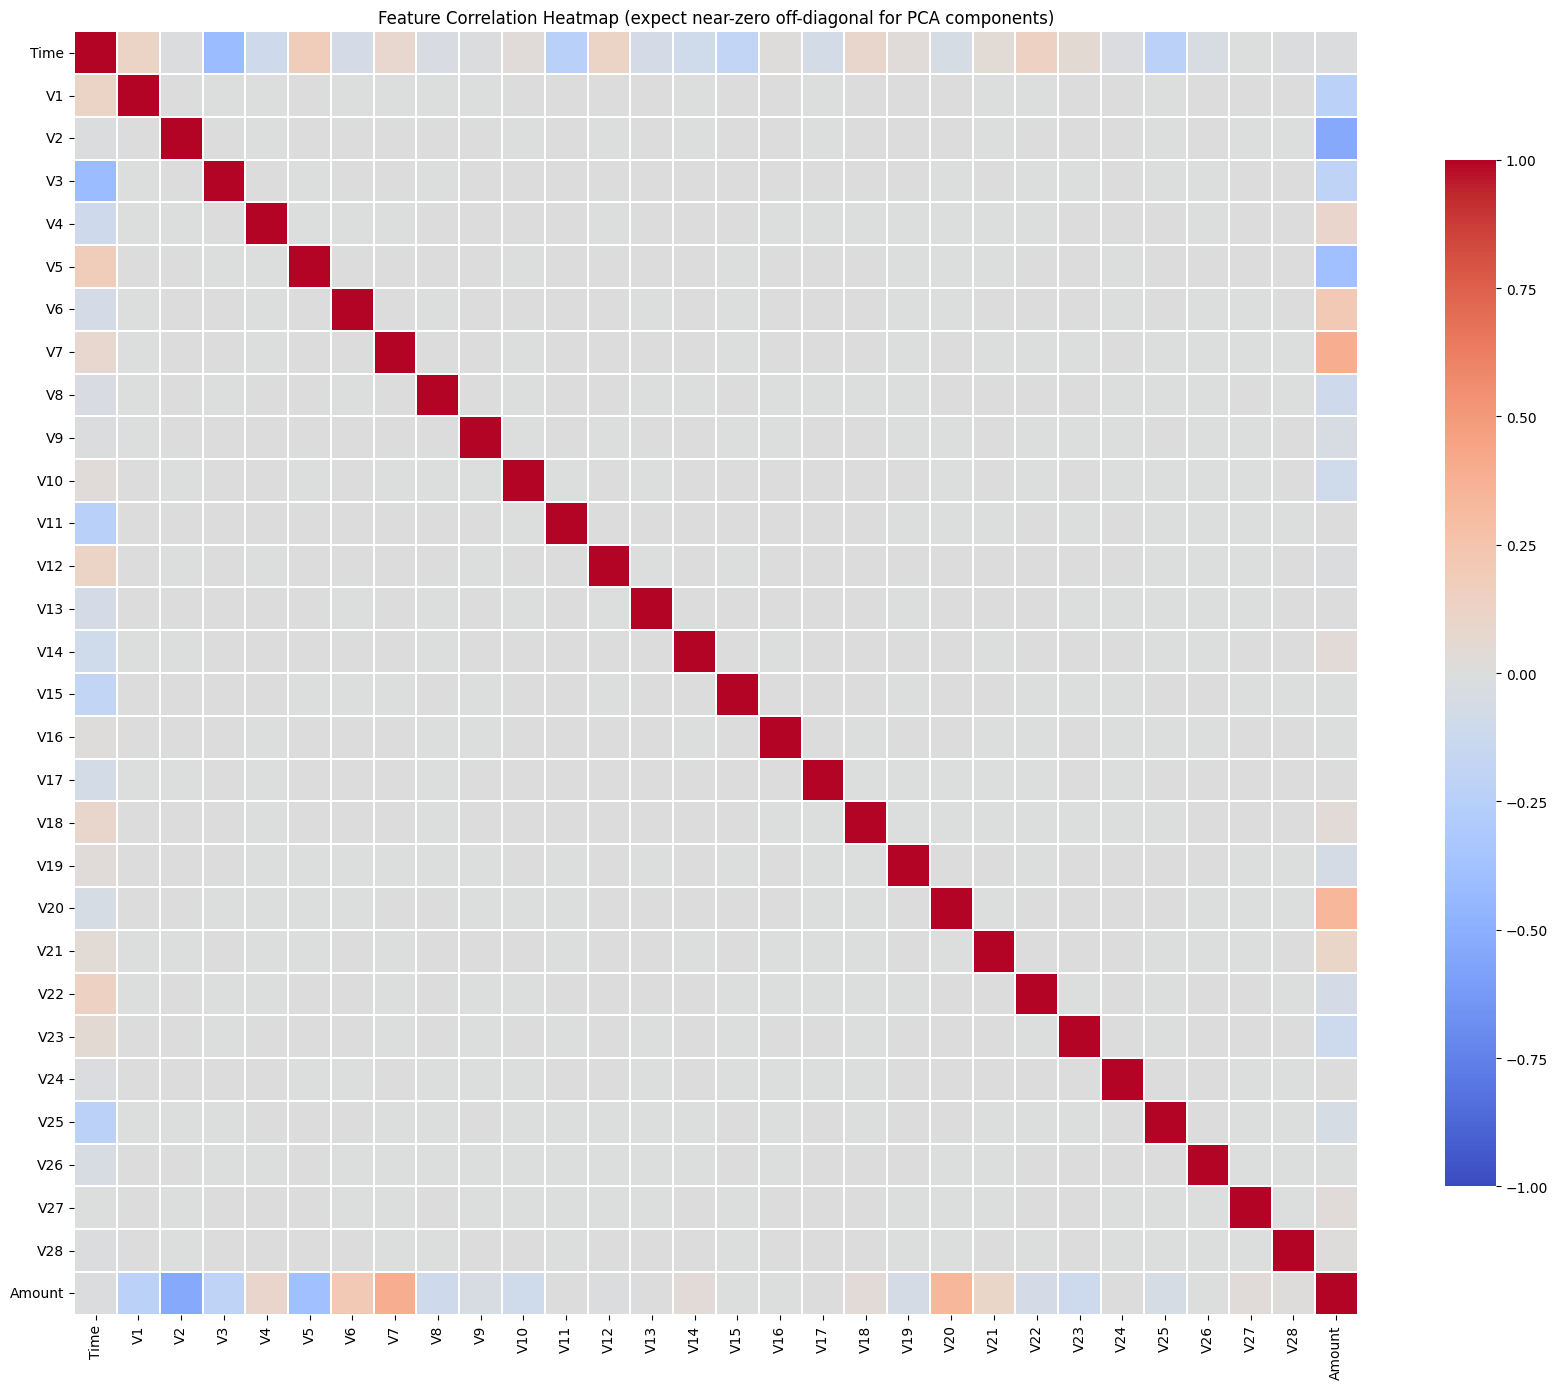

In [0]:
#exclude Class from correlation matrix
feature_cols = [c for c in df.columns if c != 'Class']
corr_matrix = df[feature_cols].corr()

#correlation heatmap grid where each cell shows the Pearson correlation coefficient between two features, coloured by strength - typically dark red for strong positive correlation, dark blue for strong negative, and near-white for zero correlation.
fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    ax=ax,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8}
)
ax.set_title('Feature Correlation Heatmap (expect near-zero off-diagonal for PCA components)')
plt.tight_layout()
plt.show()

### Phase 2: Experiment Tracking and Model Training
##### Train-test split 

In [0]:
#split the data into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('Class', axis=1), df['Class'], test_size=0.2, random_state=42)

#scale the features using StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### 1. Baseline Model: Random Forest with no class imbalance handling 

In [0]:
#enable autologging with MLflow to track experiments 
import mlflow
import mlflow.sklearn

mlflow.sklearn.autolog()

In [0]:
from sklearn.metrics import average_precision_score, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

#everything inside this block gets logged as one run in mlflow log 
with mlflow.start_run(run_name="baseline_no_imbalance_handling"):
    #train random forest classifier on training set 
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=15, #prevents fully grown trees
        n_jobs=-1, #parallelise across all cores
        random_state=42)
    rf.fit(X_train_scaled, y_train)
    
    y_proba = rf.predict_proba(X_test_scaled)[:, 1]
    
    #log custom metrics manually alongside autologged ones
    mlflow.log_metric("auprc", average_precision_score(y_test, y_proba))


2026/08/10 10:18:27 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
🔗 View Logged Model at: https://dbc-a6edf755-2267.cloud.databricks.com/ml/experiments/1750975291163841/models/m-ea81a953d5e34c9d8c04f4700ff7ef5b?o=7474646628912911


#### 2. Random Forest with class_weight = 'balanced'

In [0]:
%pip install hyperopt imbalanced-learn

Looking in indexes: [REDACTED]
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, classification_report, roc_auc_score
import mlflow
import numpy as np

#define the search space
search_space = {
    'n_estimators': hp.choice('n_estimators', [50, 100, 200]),
    'max_depth': hp.choice('max_depth', [5, 10, 15, 20]),
}

#define the objective function — HyperOpt minimises, so negate AUPRC
def objective(params):
    with mlflow.start_run(run_name="hyperopt_trial", nested=True):
        
        rf = RandomForestClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            class_weight='balanced', #set imbalance handling on
            n_jobs=-1,
            random_state=42
        )
        
        rf.fit(X_train_scaled, y_train)

        y_proba = rf.predict_proba(X_test_scaled)[:, 1]
        
        #log custom metrics manually alongside autologged ones
        auprc = average_precision_score(y_test, y_proba)
        mlflow.log_metric("auprc", auprc)
    
    #HyperOpt minimises, so return negative AUPRC
    return {'loss': -auprc, 'status': STATUS_OK}

#run HyperOpt under a parent MLflow run
with mlflow.start_run(run_name="hyperopt_class_weighted"):
    trials = Trials()
    best_params = fmin(
        fn=objective,
        space=search_space,
        algo=tpe.suggest, #bayesian optimisation algorithm
        max_evals=8, #keep low given runtime
        trials=trials
    )

print("Best parameters found:", best_params)

  0%|          | 0/8 [00:00<?, ?trial/s, best loss=?]

2026/08/10 10:33:17 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'

🔗 View Logged Model at: https://dbc-a6edf755-2267.cloud.databricks.com/ml/experiments/1750975291163841/models/m-cc08c73870664731bd6bfb6b9417619d?o=7474646628912911


 12%|█▎        | 1/8 [03:02<21:17, 182.44s/trial, best loss: -0.8465122330046597]

2026/08/10 10:36:19 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'

🔗 View Logged Model at: https://dbc-a6edf755-2267.cloud.databricks.com/ml/experiments/1750975291163841/models/m-354ec1e5aa8a4ef2acfe4f3f32ba2f33?o=7474646628912911


 25%|██▌       | 2/8 [04:38<13:08, 131.35s/trial, best loss: -0.8699809122335951]

...

 75%|███████▌  | 6/8 [13:10<03:52, 116.09s/trial, best loss: -0.8732311160603211]

2026/08/10 10:46:28 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'

🔗 View Logged Model at: https://dbc-a6edf755-2267.cloud.databricks.com/ml/experiments/1750975291163841/models/m-3782700aa8e440828a81398097abc4e5?o=7474646628912911


 88%|████████▊ | 7/8 [14:45<01:49, 109.23s/trial, best loss: -0.8732311160603211]

2026/08/10 10:48:03 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'

🔗 View Logged Model at: https://dbc-a6edf755-2267.cloud.databricks.com/ml/experiments/1750975291163841/models/m-28105a96f59b44f7bcba95d41f237c97?o=7474646628912911


100%|██████████| 8/8 [15:43<00:00, 117.95s/trial, best loss: -0.8732311160603211]
Best parameters found: {'max_depth': np.int64(2), 'n_estimators': np.int64(2)}


#### 3. Random Forest trained on data upsampled with SMOTE (Synthetic Minority Oversampling Technique)

In [0]:
from imblearn.over_sampling import SMOTE

#apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training set shape: {X_train_scaled.shape}")
print(f"Resampled training set shape: {X_train_smote.shape}")

2026/08/10 10:57:13 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '0a0d828ec0f84264af2499e0d752d131', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/10 10:57:13 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
🔗 View Logged Model at: https://dbc-a6edf755-2267.cloud.databricks.com/ml/experiments/1750975291163841/models/m-35b8bf5617234c2db1f887d36da82767?o=7474646628912911
2026/08/10 10:57:13 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/10 10:57:16 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logg

Original training set shape: (227845, 30)
Resampled training set shape: (454902, 30)


In [0]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, classification_report, roc_auc_score
import mlflow
import numpy as np

#define the search space
search_space = {
    'n_estimators': hp.choice('n_estimators', [50, 100, 200]),
    'max_depth': hp.choice('max_depth', [5, 10, 15, 20]),
}

#define the objective function — HyperOpt minimises, so negate AUPRC
def objective(params):
    with mlflow.start_run(run_name="smote_trial", nested=True):
        
        rf = RandomForestClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            class_weight='balanced', #set imbalance handling on
            n_jobs=-1,
            random_state=42
        )
        
        rf.fit(X_train_smote, y_train_smote)

        y_proba = rf.predict_proba(X_test_scaled)[:, 1]
        
        #log custom metrics manually alongside autologged ones
        auprc = average_precision_score(y_test, y_proba)
        mlflow.log_metric("auprc", auprc)
    
    #HyperOpt minimises, so return negative AUPRC
    return {'loss': -auprc, 'status': STATUS_OK}

#run HyperOpt under a parent MLflow run
with mlflow.start_run(run_name="smote"):
    trials = Trials()
    best_params = fmin(
        fn=objective,
        space=search_space,
        algo=tpe.suggest, #bayesian optimisation algorithm
        max_evals=8, #keep low given runtime
        trials=trials
    )

print("Best parameters found:", best_params)

  0%|          | 0/8 [00:00<?, ?trial/s, best loss=?]

2026/08/10 11:03:48 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'

🔗 View Logged Model at: https://dbc-a6edf755-2267.cloud.databricks.com/ml/experiments/1750975291163841/models/m-a2c5b39d53044e6a9161a59b6c691113?o=7474646628912911


 12%|█▎        | 1/8 [03:30<24:30, 210.02s/trial, best loss: -0.8409490572199037]

2026/08/10 11:07:18 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'

🔗 View Logged Model at: https://dbc-a6edf755-2267.cloud.databricks.com/ml/experiments/1750975291163841/models/m-de5ced12140b47ebb0dd685b531ac854?o=7474646628912911


 25%|██▌       | 2/8 [10:20<32:48, 328.10s/trial, best loss: -0.8479646837078724]

...

 75%|███████▌  | 6/8 [25:53<09:33, 286.76s/trial, best loss: -0.8679380934636136]

2026/08/10 11:29:41 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'

🔗 View Logged Model at: https://dbc-a6edf755-2267.cloud.databricks.com/ml/experiments/1750975291163841/models/m-5d0fd118710a49588cc0e5b288a5e02a?o=7474646628912911


 88%|████████▊ | 7/8 [28:11<03:58, 238.39s/trial, best loss: -0.8679380934636136]

2026/08/10 11:32:00 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'

🔗 View Logged Model at: https://dbc-a6edf755-2267.cloud.databricks.com/ml/experiments/1750975291163841/models/m-26980326e6034ab49d6344088f3a946a?o=7474646628912911


100%|██████████| 8/8 [31:59<00:00, 239.96s/trial, best loss: -0.8679380934636136]
Best parameters found: {'max_depth': np.int64(2), 'n_estimators': np.int64(1)}


#### Log best model to Unity Catalog Model Registry 
Best performing model is the Random Forest with class_weight = 'balanced' using n_estimators, max_depth = 100, 20 - these optimal hyperparameters were found using HyperOpt. Comparing against different models with average precision score due to the high class imbalance, this best performing model achieved an average precision score of 0.8798.

In [0]:
import mlflow 
from sklearn.metrics import average_precision_score, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

with mlflow.start_run(run_name="credit_card_fraud_detection"):
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    )
    rf.fit(X_train_scaled, y_train)

    y_proba = rf.predict_proba(X_test_scaled)[:, 1]

    mlflow.log_metric("auprc", average_precision_score(y_test, y_proba))

2026/08/10 11:39:56 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
🔗 View Logged Model at: https://dbc-a6edf755-2267.cloud.databricks.com/ml/experiments/1750975291163841/models/m-acbc8f22d1a64ab59f02e453e1a37bd6?o=7474646628912911
